<a href="https://colab.research.google.com/github/01l01/Tensorflow/blob/main/Predict_closed_SoF_questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Note: We need GPU to train our data, enable it from settings before presenting in Class!!!!!

!nvidia-smi

Sun Dec 14 16:31:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   30C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
import keras_nlp
import os
from google.colab import drive

# 1. Mount Drive (to access the saved model)
drive.mount('/content/drive')

# 2. Re-set the legacy Keras environment variable (if you used it during saving)
os.environ['TF_USE_LEGACY_KERAS'] = '1'

Mounted at /content/drive


In [3]:
# !pip uninstall -y tensorflow tensorflow-text tensorflow-hub tf-keras

# !pip install tensorflow==2.19.0 tensorflow-text==2.19.0 tensorflow-hub==0.16.1 tf-keras==2.19.0

# import os
# os.kill(os.getpid(), 9)

In [4]:
import tensorflow_text as text

In [5]:
# necessary imports -->
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [6]:
import pandas as pd
import kagglehub
import os


csv_path = "/content/drive/MyDrive/filtered_dataset_final.csv"
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
df.shape


Using CSV: /content/drive/MyDrive/filtered_dataset_final.csv


(16224, 8)

In [7]:
# sample from dataset
df.tail(5)

,Title,BodyMarkdown,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus
16219,Python: Message the function I'm in,I'm editing some Python code with rather long ...,emacs,elisp,python,NaN,NaN,open
16220,"""Seamless"" multi user session in linux/X11",The goal\r\n-\r\n\r\nI would love to have a mu...,linux,x11,xinput,NaN,NaN,off topic
16221,XCode - Global Function self.view,So i followed [this tutorial][1] on how to cre...,iphone,objective-c,xcode,cocoa,application,open
16222,How to inizialize connection string,In my inizialisation class I have to variants ...,c#,connection-string,NaN,NaN,NaN,not a real question
16223,"Single Sign On Issue with Active Directory, II...","Currently I have a server (PHP, IIS7) setup (w...",php,iis7,active-directory,single-sign-on,NaN,not a real question


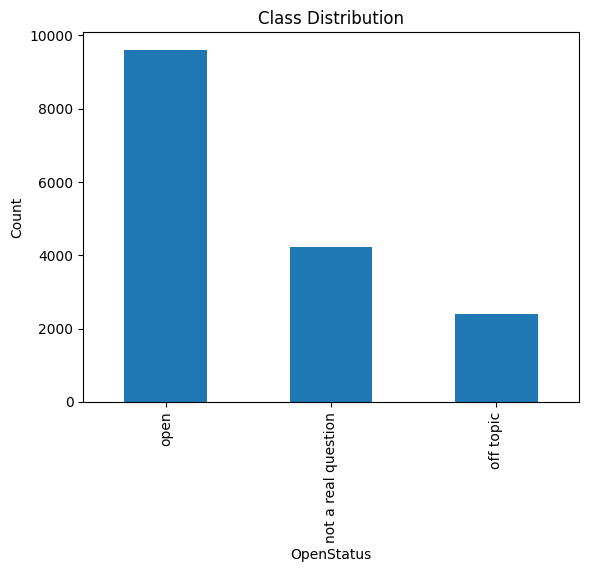

In [8]:
import matplotlib.pyplot as plt
"""
Here we have 5 different question status :
1. Open
2. not real question
3. off topic
"""
df['OpenStatus'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('OpenStatus')
plt.ylabel('Count')
plt.show()

In [9]:
# statistics fro each status -> (number of questions)

class_distribution = df['OpenStatus'].value_counts()
print(class_distribution)

OpenStatus
open                   9603
not a real question    4222
off topic              2399
Name: count, dtype: int64


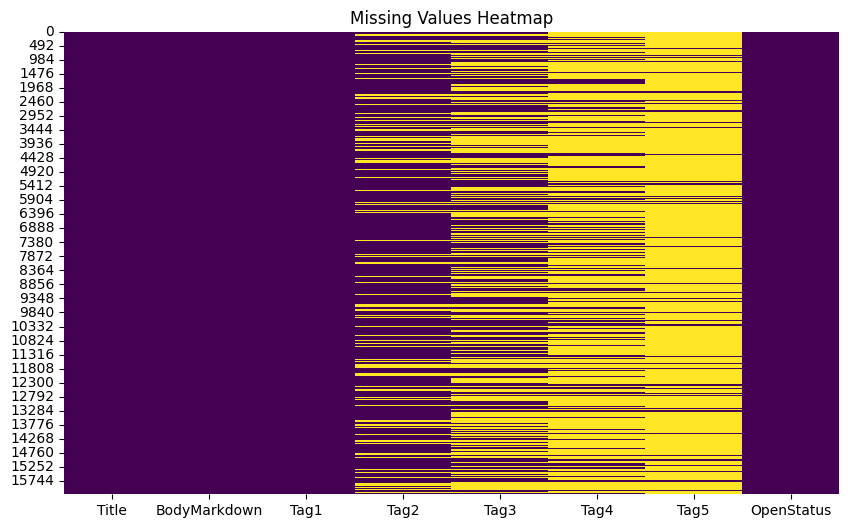

In [10]:
import seaborn as sns

# check missing values before we start training ..
# ofc all missing values related to tags and thats totally fine for us
missing_values = df.isnull()

plt.figure(figsize=(10, 6))
sns.heatmap(missing_values, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

min_size = df['OpenStatus'].value_counts().min()

balanced_df = (
    df.groupby('OpenStatus', group_keys=False)
      .apply(lambda x: x.sample(min_size, random_state=42))
)

#  train, validation and test splitting  (70%,20% ,10% )
train_df, remaining = train_test_split(balanced_df, random_state=42, train_size=0.7, stratify=balanced_df['OpenStatus'])
valid_df, test_df = train_test_split(remaining, random_state=42, train_size=0.6667, stratify=remaining.OpenStatus.values)


train_df.shape, valid_df.shape, test_df.shape

/tmp/ipython-input-2825488393.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_size, random_state=42))


((5037, 8), (1440, 8), (720, 8))

In [12]:
# only for training dataset
class_distribution = train_df['OpenStatus'].value_counts()
print(class_distribution)

OpenStatus
off topic              1679
open                   1679
not a real question    1679
Name: count, dtype: int64


In [13]:
from sklearn.utils import resample


open_class = train_df[train_df.OpenStatus == 'open']
not_a_real_question_class = train_df[train_df.OpenStatus == 'not a real question']
off_topic_class = train_df[train_df.OpenStatus == 'off topic']


# Downsampling the  classes to the size of the 'off topic' class
open_class = resample(open_class,
                      replace=False,  # sample without replacement
                      n_samples=len(off_topic_class),  # match target class size
                      random_state=42)  # for reproducible results

not_a_real_question_class = resample(not_a_real_question_class,
                                     replace=False,  # sample without replacement
                                     n_samples=len(off_topic_class),  # match target class size
                                     random_state=42)  # for reproducible results



# Combining all the minority class with the resampled classes
train_df = pd.concat([open_class,
                not_a_real_question_class,
                off_topic_class,
                ])

# Shuffle the downsampled training dataset
train_df = train_df.sample(frac=1, random_state=42)

In [14]:
train_df.shape

(5037, 8)

In [15]:
# Checking the number of samples from each class of train_df

class_distribution = train_df['OpenStatus'].value_counts()
print(class_distribution)

OpenStatus
off topic              1679
not a real question    1679
open                   1679
Name: count, dtype: int64


In [16]:
train_df.tail(5)

,Title,BodyMarkdown,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus
7559,htaccess - internet server error 500 on XAMPP,"I am trying to run script on XAMPP but get ""in...",apache,.htaccess,xampp,NaN,NaN,off topic
8215,Moving cell to the top of the UITableView,I have UITable with items filled in from a NSM...,iphone,objective-c,uitableview,uitableviewcell,NaN,open
2142,LinqToSQL Select and SelectMany vs Join,Are Select and SelectMany preferrable to Joins...,linq-to-sql,NaN,NaN,NaN,NaN,not a real question
10205,Who has the usb cable driver of the Alcatel OT...,I want to install the `USB cable driver` of my...,usb,device-driver,usbserial,alcatel-ot,NaN,off topic
3274,isset() with dynamic property names,Why does `isset()` not work when the property ...,php,oop,NaN,NaN,NaN,open


In [17]:
# comibne title, tags and BodyMarkdown to create a SINGLE text input (:

for index, row in train_df.iterrows():
    text = "Title: " + "'" + row.Title + "'"
    #text += " Tags: {" + ', '.join(str(tag) for tag in [row.Tag1, row.Tag2, row.Tag3, row.Tag4, row.Tag5] if not pd.isnull(tag)) + "}"
    text += "  Body: " + "'" + row.BodyMarkdown + "'"
    train_df.at[index, 'text'] = text


for index, row in valid_df.iterrows():
    text = "Title: " + "'" + row.Title + "'"
    #text += " Tags: {" + ', '.join(str(tag) for tag in [row.Tag1, row.Tag2, row.Tag3, row.Tag4, row.Tag5] if not pd.isnull(tag)) + "}"
    text += "  Body: " + "'" + row.BodyMarkdown + "'"
    valid_df.at[index, 'text'] = text

for index, row in test_df.iterrows():
    text = "Title: " + "'" + row.Title + "'"
    #text += " Tags: {" + ', '.join(str(tag) for tag in [row.Tag1, row.Tag2, row.Tag3, row.Tag4, row.Tag5] if not pd.isnull(tag)) + "}"
    text += "  Body: " + "'" + row.BodyMarkdown + "'"
    test_df.at[index, 'text'] = text

In [18]:
train_df.tail(5)

,Title,BodyMarkdown,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus,text
7559,htaccess - internet server error 500 on XAMPP,"I am trying to run script on XAMPP but get ""in...",apache,.htaccess,xampp,NaN,NaN,off topic,Title: 'htaccess - internet server error 500 o...
8215,Moving cell to the top of the UITableView,I have UITable with items filled in from a NSM...,iphone,objective-c,uitableview,uitableviewcell,NaN,open,Title: 'Moving cell to the top of the UITableV...
2142,LinqToSQL Select and SelectMany vs Join,Are Select and SelectMany preferrable to Joins...,linq-to-sql,NaN,NaN,NaN,NaN,not a real question,Title: 'LinqToSQL Select and SelectMany vs Joi...
10205,Who has the usb cable driver of the Alcatel OT...,I want to install the `USB cable driver` of my...,usb,device-driver,usbserial,alcatel-ot,NaN,off topic,Title: 'Who has the usb cable driver of the Al...
3274,isset() with dynamic property names,Why does `isset()` not work when the property ...,php,oop,NaN,NaN,NaN,open,Title: 'isset() with dynamic property names' ...


In [19]:
columns_to_drop = ['Title', 'BodyMarkdown']
train_df.drop(columns=columns_to_drop, inplace=True)
valid_df.drop(columns=columns_to_drop, inplace=True)
test_df.drop(columns=columns_to_drop, inplace=True)

In [20]:
train_df.tail(5)

,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus,text
7559,apache,.htaccess,xampp,NaN,NaN,off topic,Title: 'htaccess - internet server error 500 o...
8215,iphone,objective-c,uitableview,uitableviewcell,NaN,open,Title: 'Moving cell to the top of the UITableV...
2142,linq-to-sql,NaN,NaN,NaN,NaN,not a real question,Title: 'LinqToSQL Select and SelectMany vs Joi...
10205,usb,device-driver,usbserial,alcatel-ot,NaN,off topic,Title: 'Who has the usb cable driver of the Al...
3274,php,oop,NaN,NaN,NaN,open,Title: 'isset() with dynamic property names' ...


In [21]:
# Example :::
for index, row in train_df.iterrows():
    print("Text: ")
    print("________________________")
    print(row.text, end='\n\n\n\n')
    print("Target Class:")
    print("________________________")
    print(row.OpenStatus)
    break

Text: 
________________________
Title: 'How do you tell someone they're writing bad code?'  Body: 'I've been working with a small group of people on a coding project for fun.  It's an organized and fairly cohesive group.  The people I work with all have various skill sets related to programming, but some of them use older or outright wrong methods, such as excessive global variables, poor naming conventions, and other things.  While things work, the implementation is poor.  What's a good way to politely ask or introduce them to use better methodology, without it coming across as questioning (or insulting) their experience and/or education?'



Target Class:
________________________
off topic


In [22]:
# Definelabel mapping
custom_label_mapping = {'open': 0,
                        'not a real question': 1,
                        'off topic': 2,
                       }

# Initialize LabelEncoder with custom mapping
encoded_labels = []
for index, row in train_df.iterrows():
    label = row['OpenStatus']
    encoded_label = custom_label_mapping[label]
    encoded_labels.append(encoded_label)

# Add the encoded labels as a new column in the DataFrame
train_df['OpenStatus_encoded'] = encoded_labels



# Applying the same changes to valid_df and test_df

encoded_labels = []
for index, row in valid_df.iterrows():
    label = row['OpenStatus']
    encoded_label = custom_label_mapping[label]
    encoded_labels.append(encoded_label)

# Add the encoded labels as a new column in the DataFrame
valid_df['OpenStatus_encoded'] = encoded_labels



encoded_labels = []
for index, row in test_df.iterrows():
    label = row['OpenStatus']
    encoded_label = custom_label_mapping[label]
    encoded_labels.append(encoded_label)

# Add the encoded labels as a new column in the DataFrame
test_df['OpenStatus_encoded'] = encoded_labels

In [23]:
train_df.tail(5)

,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus,text,OpenStatus_encoded
7559,apache,.htaccess,xampp,NaN,NaN,off topic,Title: 'htaccess - internet server error 500 o...,2
8215,iphone,objective-c,uitableview,uitableviewcell,NaN,open,Title: 'Moving cell to the top of the UITableV...,0
2142,linq-to-sql,NaN,NaN,NaN,NaN,not a real question,Title: 'LinqToSQL Select and SelectMany vs Joi...,1
10205,usb,device-driver,usbserial,alcatel-ot,NaN,off topic,Title: 'Who has the usb cable driver of the Al...,2
3274,php,oop,NaN,NaN,NaN,open,Title: 'isset() with dynamic property names' ...,0


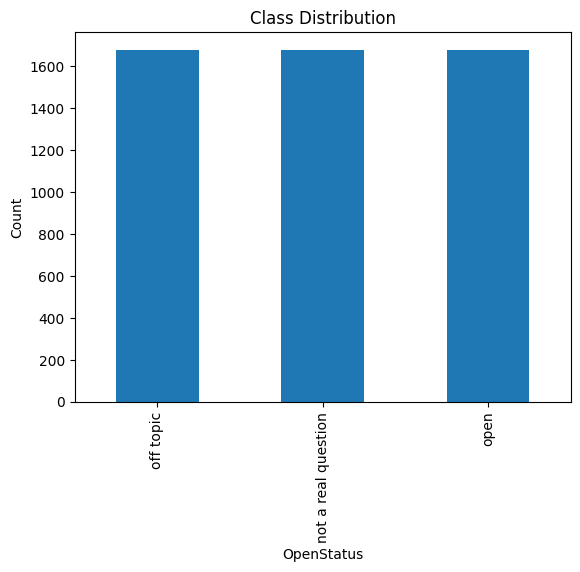

In [24]:
train_df['OpenStatus'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('OpenStatus')
plt.ylabel('Count')
plt.show()

In [25]:
X_train = train_df["text"]
y_train = train_df["OpenStatus_encoded"]

X_valid = valid_df["text"]
y_valid = valid_df["OpenStatus_encoded"]

X_test = test_df["text"]
y_test = test_df["OpenStatus_encoded"]

In [26]:
print(X_train.shape)
print(y_train.shape)

print(X_valid.shape)
print(y_valid.shape)

print(X_test.shape)
print(y_test.shape)

(5037,)
(5037,)
(1440,)
(1440,)
(720,)
(720,)


In [27]:
### 5. Checking the tokenization process
# preprocessor = hub.KerasLayer(
#     "https://kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-preprocess/versions/3")

# input_text = ["Hello, how are you?"]
# tokenized_output = preprocessor(input_text)

# print(tokenized_output['input_word_ids'])
# print(tokenized_output['input_mask'])
# print(tokenized_output['input_type_ids'])
!pip install keras-nlp
# You should also ensure you have a compatible version of Keras Core if needed,
# but installing keras-nlp usually pulls in the right dependencies.

In [44]:
import tensorflow as tf
import keras_nlp
# We still use standard Keras layers from tf.keras
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, Dense
from tensorflow.keras import Model
import os
import random
from tensorflow.keras import regularizers

SEED = int(os.environ.get("SEED", "42"))
L2_REG = float(os.environ.get("L2_REG", "0.0"))
ES_PATIENCE = int(os.environ.get("ES_PATIENCE", "3"))
RLR_PATIENCE = int(os.environ.get("RLR_PATIENCE", "2"))
RLR_FACTOR = float(os.environ.get("RLR_FACTOR", "0.5"))
MIN_LR = float(os.environ.get("MIN_LR", "1e-6"))
try:
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
except Exception as _seed_e:
    print(f"Seed setup skipped: {_seed_e}")



# 1. Input Layer (Created outside the scope, as it's just a placeholder)
text_input = Input(shape=(), name="Input", dtype=tf.string)

# 2. Preprocessor (KerasNLP) - Uses strings, so no need for device assignment
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    "bert_base_en_uncased", # previously used "bert_tiny_en_uncased" now trying wiht "bert_base_en_uncased" for fine-tuning!
    sequence_length=128 # Tried with 96, Now increasing to 128 for better results!
)
encoder_inputs = preprocessor(text_input)


# 3. Define the Distribution Strategy
try:
    # Use OneDeviceStrategy to explicitly target the GPU for training
    strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
    print("Defined OneDeviceStrategy for /gpu:0.")
except RuntimeError:
    # Fallback to CPU if GPU device is not detected
    strategy = tf.distribute.OneDeviceStrategy(device="/cpu:0")
    print("GPU not available, falling back to OneDeviceStrategy for /cpu:0.")


# 4. Build and Compile the Model within the Strategy Scope
with strategy.scope():
    # === CRITICAL FIX: Nest CPU assignment inside the strategy scope ===
    # This tells the strategy that the variables are being created on the CPU,
    # but they are still under the strategy's management.
    with tf.device('/cpu:0'):
        # 4a. Encoder (KerasNLP Backbone) - Variables are created here (on CPU)
        encoder = keras_nlp.models.BertBackbone.from_preset(
            "bert_base_en_uncased"
        )
        # KerasNLP backbones return a dictionary of outputs.
        outputs = encoder(encoder_inputs)

    # Use the correct dictionary key: "pooled_output" for classification
    pooled_output = outputs["pooled_output"]
    # sequence_output = outputs["sequence_output"] # Not used in classification head

    # 4b. Classification layers (Simplified to conserve GPU memory)
    drop1 = tf.keras.layers.Dropout(0.2)(pooled_output)
    batch_norm1 = tf.keras.layers.BatchNormalization()(drop1)


    reg = regularizers.l2(L2_REG) if L2_REG > 0 else None
    hidden1 = tf.keras.layers.Dense(196, activation='relu', kernel_regularizer=reg)(batch_norm1) # tried with 256,196
    # drop2 = tf.keras.layers.Dropout(0.2)(hidden1)
    # batch_norm2 = tf.keras.layers.BatchNormalization()(drop2)
    # hidden2 = tf.keras.layers.Dense(128, activation='relu')(batch_norm2)
    # drop3 = tf.keras.layers.Dropout(0.3)(hidden2)
    # batch_norm3 = tf.keras.layers.BatchNormalization()(drop3)
    # hidden3 = tf.keras.layers.Dense(32, activation='relu')(batch_norm3)
    # drop4 = tf.keras.layers.Dropout(0.2)(hidden3)
    # batch_norm4 = tf.keras.layers.BatchNormalization()(drop4)

    output_layer = tf.keras.layers.Dense(3, activation='softmax', name='output', kernel_regularizer=reg)(hidden1)


    # 4c. Create the model instance
    model = tf.keras.Model(inputs=[text_input], outputs=[output_layer])

    # 4d. Configure the model compilation

    loss_obj = tf.keras.losses.SparseCategoricalCrossentropy()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-6, clipnorm=1.0)
    model.compile(
        optimizer=optimizer,
        loss=loss_obj, # Since y_train is dtype: int64
        metrics=['accuracy']
    )

model.summary()

Defined OneDeviceStrategy for /gpu:0.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_text_classifi… │ [(None, 128),     │          0 │ Input[0][0]       │
│ (BertTextClassifie… │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 109,482,2… │ bert_text_classi… │
│ (BertBackbone)      │ (None, 128, 768)] │            │ bert_text_classi… │
│                     │                   │            │ bert_text_classi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 768)       │          0 │ bert_backbone[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 768)       │      3,072 │ dropout_38[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196)       │    150,724 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        591 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,636,627 (418.23 MB)

 Trainable params: 109,635,091 (418.22 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [30]:
# Define callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
       filepath='best_model.weights.h5',
        save_best_only=True,
        monitor='val_accuracy',
        save_weights_only=True,
        verbose=1,
        save_freq='epoch'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=3,  # Number of epochs with no improvement after which training will be stopped
        monitor='val_accuracy',  # Quantity to be monitored
        restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
    ),
     tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',  # reduce LR on loss for stability
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

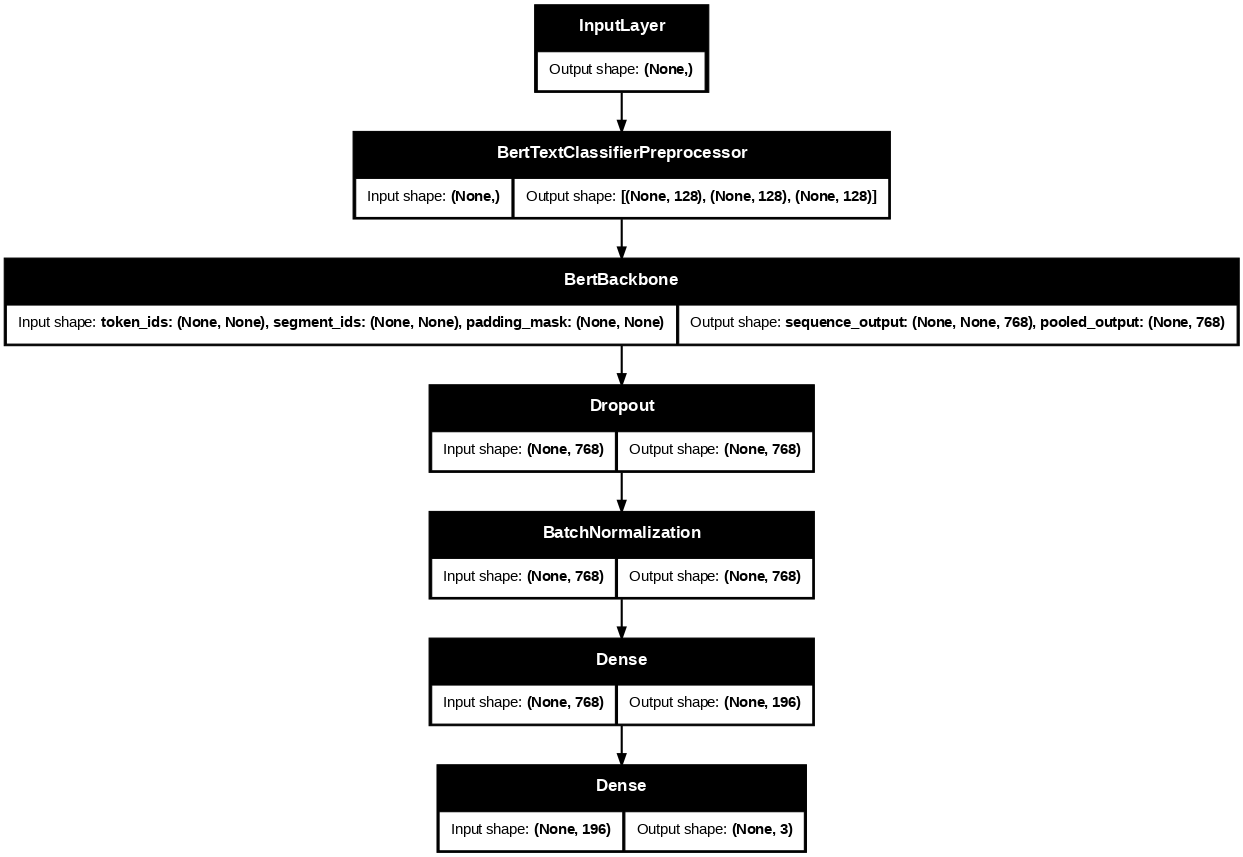

In [31]:
# Plot the model architecture
tf.keras.utils.plot_model(model, show_shapes=True, dpi=76)

In [32]:
# import numpy as np

# # Assuming X_train, y_train, X_valid, y_valid are available in your environment
print(f"X_train Shape: {X_train.shape}, Dtype: {X_train.dtype}")
print(f"y_train Shape: {y_train.shape}, Dtype: {y_train.dtype}")
print(f"X_valid Shape: {X_valid.shape}, Dtype: {X_valid.dtype}")
print(f"y_valid Shape: {y_valid.shape}, Dtype: {y_valid.dtype}")

X_train Shape: (5037,), Dtype: object
y_train Shape: (5037,), Dtype: int64
X_valid Shape: (1440,), Dtype: object
y_valid Shape: (1440,), Dtype: int64


In [33]:
#conver X_train to String
X_train = X_train.astype("string")
X_valid = X_valid.astype("string")

In [34]:
X_train

,text
16003,Title: 'How do you tell someone they're writin...
1472,Title: 'Portable python ssh module' Body: 'I'...
1780,Title: 'Metal price API' Body: 'Is there any ...
14547,Title: 'how to debug the code which is hang' ...
885,Title: 'how to store product details in cart i...
...,...
7559,Title: 'htaccess - internet server error 500 o...
8215,Title: 'Moving cell to the top of the UITableV...
2142,Title: 'LinqToSQL Select and SelectMany vs Joi...
10205,Title: 'Who has the usb cable driver of the Al...


In [35]:
# import tensorflow as tf

# # 1. Define a Batch Size
# # BERT models usually perform best with a small batch size.
BATCH_SIZE = 32

epochs = 10

# # Pass the datasets directly to model.fit()
# history = model.fit(X_train,
#                     y_train,
#                     validation_data = (X_valid, y_valid),
#                     epochs=epochs,
#                     verbose=1,
#                     callbacks=callbacks,
#                     batch_size=BATCH_SIZE
#                    )
from sklearn.utils.class_weight import compute_class_weight
unique_classes = np.unique(y_train)
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)
class_weight = {int(c): float(w) for c, w in zip(unique_classes, class_weights_values)}
print("Class weights:", class_weight)

# Pass the datasets directly to model.fit()
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0}
Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4563 - loss: 1.2053
Epoch 1: val_accuracy improved from -inf to 0.60903, saving model to best_model.weights.h5
158/158 ━━━━━━━━━━━━━━━━━━━━ 56s 182ms/step - accuracy: 0.4567 - loss: 1.2043 - val_accuracy: 0.6090 - val_loss: 0.8737 - learning_rate: 2.0000e-05
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6471 - loss: 0.8297
Epoch 2: val_accuracy did not improve from 0.60903
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.6473 - loss: 0.8295 - val_accuracy: 0.5708 - val_loss: 1.0775 - learning_rate: 2.0000e-05
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7350 - loss: 0.6487
Epoch 3: val_accuracy improved from 0.60903 to 0.66944, saving model to best_model.weights.h5
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.7351 - loss: 0.6485 - val_accuracy: 0.6694 - val_loss: 0.9797 - learning_rate: 2.0000e-05
Epoch 4/10
158/1

In [36]:
to_class_map = {0 : 'open',
                      1 : 'not a real question',
                      2 : 'off topic',
                      }
label_to_class_map = {0 : 'open',
                      1 : 'not a real question',
                      2 : 'off topic',
                      }

In [37]:
X_test.shape
X_test.tolist()[:2]

["Title: 'java object type'  Body: 'what is the type of object in exception class?'",
 "Title: 'Is it possible to monitor calls to keybd_event, mouse_event, SetKeyboardState and SetWindowsHookEx?'  Body: 'I'm trying to develop an anti-cheating system. The system will work by identifying applications which make use of the keybd_event, mouse_event and SetKeyboardState in Windows. These applications are to be compared against a database of applications which are allowed by the system to make calls to those functions.\r\n\r\nTo do this, I need to know if there's any way I can monitor calls to certain WinAPI functions.\r\n\r\nI would also need to monitor calls to SetWindowsHookEx.'"]

In [38]:

save_path = '/content/drive/MyDrive/sof_classifier_model_vFinal.keras'

model.save(save_path)

print(f"Model saved successfully to: {save_path}")

Model saved successfully to: /content/drive/MyDrive/sof_classifier_model_vFinal.keras


___________________________________________________


TEXT:


Title: 'How do I avoid deeply nested code in node.js?'  Body: 'In node.js, it being event-driven, all I/O is done via callbacks. So I end up writing code that looks like this:

<pre><code>app.get('/test', function (req, res) {
  http.get('some/place', function (req1, res1) {
    if (res1.statusCode == 200) {
      res1.on('data', function (data) {
        http.get('other/place?q=' + data, function (req2, res2) {
          if (res2.statusCode == 200) {
            res2.on('data', function (data) {
              db.query(data).on('data', function (rows) {
                res.writeHead(200)
                res.end(JSON.stringify(rows))
              }
            }
          }
        }
      }
    }
  }
}
</pre></code>

And that doesn't even include error handling.

What can I do to unwind this mess?'



___________________________________________________


GROUND TRUTH:


open



______________________________________________

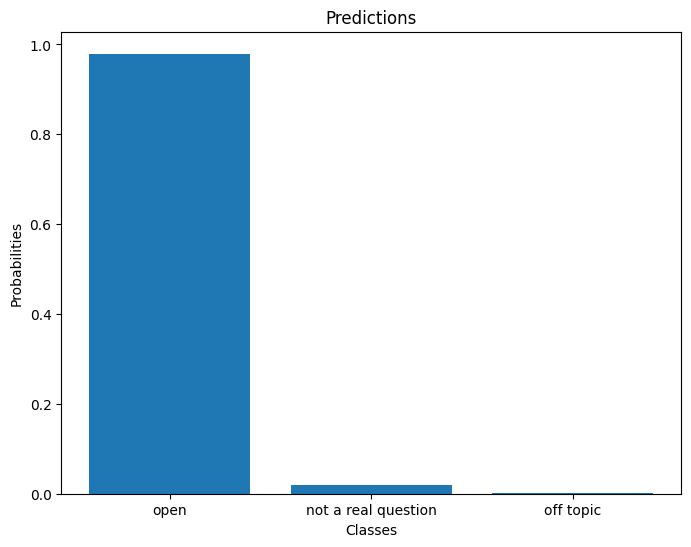




___________________________________________________


PREDICTED CLASS:  open



___________________________________________________



CORRECT PREDICTION !!!


In [40]:
# Necessary imports, assuming they are defined elsewhere in the notebook
import random
import numpy as np

# --- Assumed variables (must be defined in your notebook) ---
X_test_list = X_test.tolist()
y_test_list = y_test.tolist()
# label_to_class_map = {0: 'open', 1: 'not a real question', ...}
# model = tf.keras.Model(...)
# -----------------------------------------------------------

# Generate a random integer between 0 and 5612 (inclusive)
rand_int = random.randint(0, len(X_test_list) - 1)

# Get the text for prediction
text_to_predict = X_test_list[rand_int]

print("___________________________________________________")
print("\n\nTEXT:\n\n")
print(text_to_predict)
print("\n\n")
print("___________________________________________________")
print("\n\nGROUND TRUTH:\n\n")
print(label_to_class_map[y_test_list[rand_int]])
print("\n\n")
print("___________________________________________________")


print("\n\n")

# CRITICAL FIX: Convert the single string into a NumPy array (dtype=object)
# to ensure the Keras model correctly recognizes the string input type.
input_for_prediction = np.array([text_to_predict], dtype=object)
prediction = model.predict(input_for_prediction) # Pass the NumPy array

print("\n\nPREDICTION:\n\n")

categories = ['open',
              'not a real question',
              'off topic'
             ]

plt.figure(figsize=(8, 6))
plt.bar(categories, prediction[0])
plt.xlabel('Classes')
plt.ylabel('Probabilities')
plt.title('Predictions')
plt.show() # Renders the chart
print("\n\n")
print("___________________________________________________")



predicted_class_index = np.argmax(prediction)
print("\n\nPREDICTED CLASS: ", label_to_class_map[predicted_class_index])
print('\n\n')
print("___________________________________________________")



print("\n\n")
if label_to_class_map[predicted_class_index] == label_to_class_map[y_test_list[rand_int]]:
    print("CORRECT PREDICTION !!!")
else:
    print("WRONG PREDICTION !!!")

___________________________________________________


TEXT:


Title: 'C# places great importance on OOP - what does this mean?'  Body: 'So I have learned some parts of programming languages (Python, PHP, Javascript) and I want to learn C# for .NET, ASP, COM, and mostly to become a better programmer (so far my programming has been a mixture of web programming as well as small-scale bespoke application development - I am currently working for a web dev company, so the web programming is probably more useful).

I have heard that C# is similar to Java in that object oriented programming is very important. I have been trying to wrap my head around object oriented programming, and I get the basic idea is to make code modular - but how would this affect programming in C#? Would I have to put everything in "coding blocks" (classes?) and call them that way?

Is it not possible to write a line by line program (I believe this is called functional programming)?'



________________________________

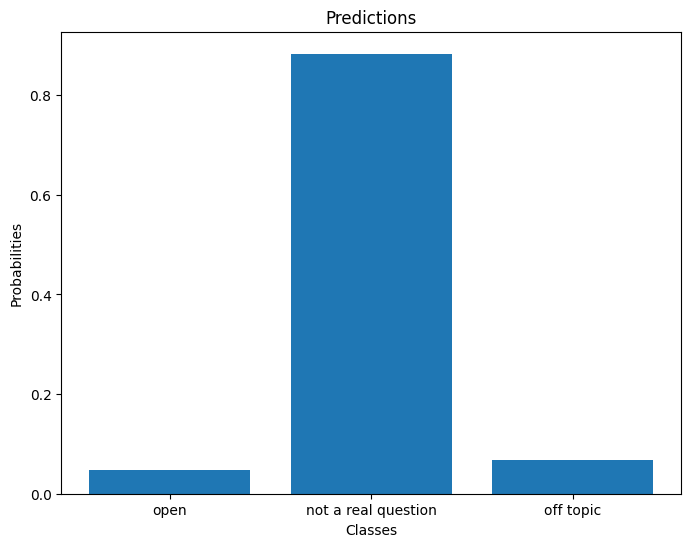




___________________________________________________


PREDICTED CLASS:  not a real question



___________________________________________________



CORRECT PREDICTION !!!


In [41]:
# Necessary imports, assuming they are defined elsewhere in the notebook
import random
import numpy as np

# --- Assumed variables (must be defined in your notebook) ---
X_test_list = X_test.tolist()
y_test_list = y_test.tolist()
# label_to_class_map = {0: 'open', 1: 'not a real question', ...}
# model = tf.keras.Model(...)
# -----------------------------------------------------------

# Generate a random integer between 0 and 5612 (inclusive)
rand_int = random.randint(0, len(X_test_list) - 1)

# Get the text for prediction
text_to_predict = X_test_list[rand_int]

print("___________________________________________________")
print("\n\nTEXT:\n\n")
print(text_to_predict)
print("\n\n")
print("___________________________________________________")
print("\n\nGROUND TRUTH:\n\n")
print(label_to_class_map[y_test_list[rand_int]])
print("\n\n")
print("___________________________________________________")


print("\n\n")

# CRITICAL FIX: Convert the single string into a NumPy array (dtype=object)
# to ensure the Keras model correctly recognizes the string input type.
input_for_prediction = np.array([text_to_predict], dtype=object)
prediction = model.predict(input_for_prediction) # Pass the NumPy array

print("\n\nPREDICTION:\n\n")

categories = ['open',
              'not a real question',
              'off topic'
             ]

plt.figure(figsize=(8, 6))
plt.bar(categories, prediction[0])
plt.xlabel('Classes')
plt.ylabel('Probabilities')
plt.title('Predictions')
plt.show() # Renders the chart
print("\n\n")
print("___________________________________________________")



predicted_class_index = np.argmax(prediction)
print("\n\nPREDICTED CLASS: ", label_to_class_map[predicted_class_index])
print('\n\n')
print("___________________________________________________")



print("\n\n")
if label_to_class_map[predicted_class_index] == label_to_class_map[y_test_list[rand_int]]:
    print("CORRECT PREDICTION !!!")
else:
    print("WRONG PREDICTION !!!")

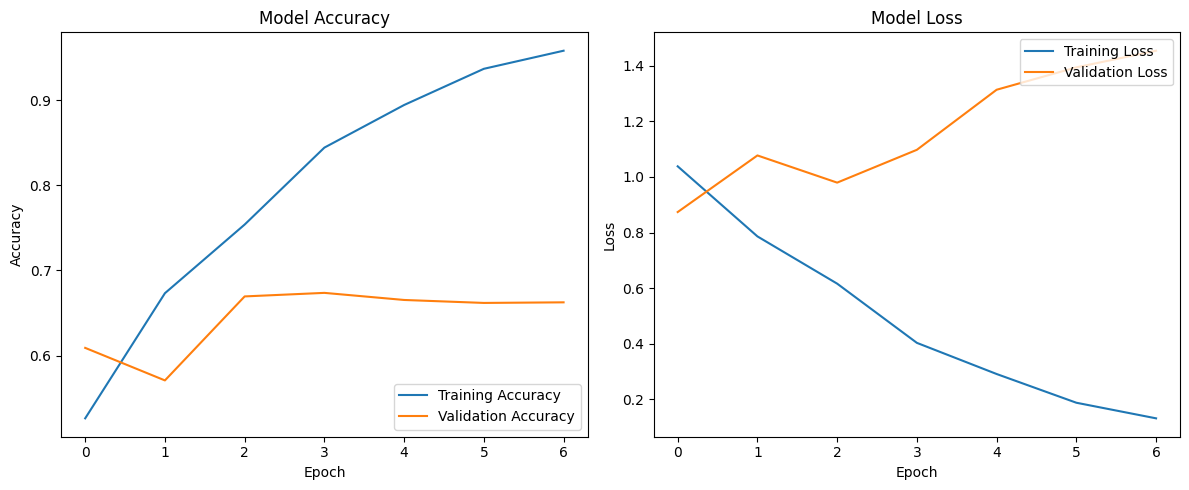

In [42]:
import matplotlib.pyplot as plt

# 1. Extract training and validation accuracy and loss
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(accuracy))

# 2. Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# 3. Adjust layout and display plots
plt.tight_layout()
plt.show()


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step


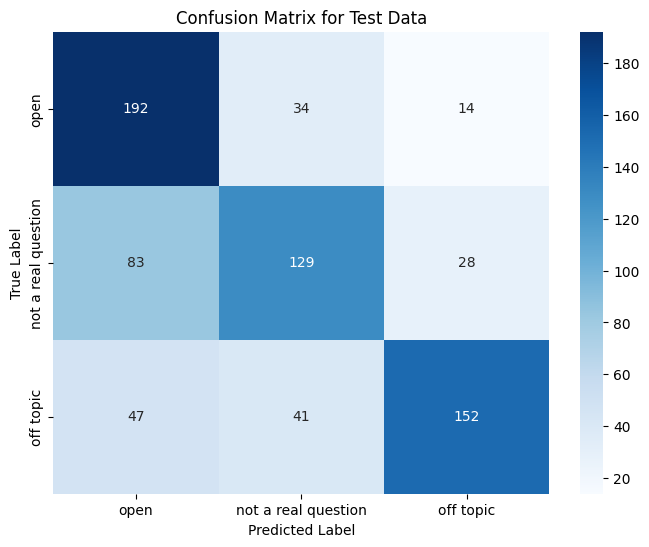

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Make predictions on the test data
X_test_array = np.array(X_test.tolist(), dtype=object) # Ensure X_test is an array of objects
y_pred_probabilities = model.predict(X_test_array)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# 2. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Define class names for plotting
class_names = [label_to_class_map[i] for i in sorted(label_to_class_map.keys())]

# 4. Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Data')
plt.show()



1. Tried with batch size 16 and 2 norms val_accurace was awful recompiled on batcgsize 32 and removed the second norm
2. Tried with batch size 32 (second norm removed), dropout 0.3 max val_accuracy gained is 0.68311, train accuracy about 0.92 clearly there is an overfitting happening. Trying again after increasing dropout to 0.5, dense 64
3. After making this changes above the val_accuracy increased to 0.70777. still not ideal yeah ?! Trying to shrink sequence_length from 128 to 64 let's see ?! Hmm the result is more worth now its about 0.67 again.